## Preprocessing Data

<img src='Img\Data-Preprocessing.jpg'>

In [1]:
import warnings 
warnings.filterwarnings('ignore')

### Handling Missing Values

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [85]:
from io import StringIO

csv_data=\
    '''A,B,C,D
     ,,,
    1.0,2.0,3.0,4.0
    5.0,6.0,,8.0
    10.0,11.0,12.0,'''

df_test=pd.read_csv(StringIO(csv_data))
df_test

,A,B,C,D
0,,NaN,NaN,NaN
1,1.0,2.0,3.0,4.0
2,5.0,6.0,NaN,8.0
3,10.0,11.0,12.0,NaN


In [81]:
df_test.dropna(axis=0)

,A,B,C,D
1,1.0,2.0,3.0,4.0


In [82]:
df_test.dropna(axis=1)

,A
0,NaN
1,1.0
2,5.0
3,10.0


In [86]:
df_test.dropna(how='all')

,A,B,C,D
0,,NaN,NaN,NaN
1,1.0,2.0,3.0,4.0
2,5.0,6.0,NaN,8.0
3,10.0,11.0,12.0,NaN


In [7]:
df_test.dropna(thresh=4)

,A,B,C,D
0,1.0,2.0,3.0,4.0


In [8]:
df_test.dropna(subset=['C'])

,A,B,C,D
0,1.0,2.0,3.0,4.0
2,10.0,11.0,12.0,NaN


In [9]:
df = pd.read_csv('Data/heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [88]:
df.isnull().sum()

id             0
age            0
dataset        0
cp             0
trestbps       0
chol           0
fbs           90
restecg        2
thalch        55
exang         55
oldpeak       62
slope          0
thal           0
num            0
sex_Female     0
sex_Male       0
dtype: int64

In [90]:
missing_values=df.isnull().sum()
missing_percentage=(missing_values/len(df))*100
missing_summary=pd.DataFrame({'Total Missing': missing_values, 'Missing Percentage (%)':missing_percentage})
missing_summary=missing_summary[missing_summary['Total Missing']>0]
missing_summary

,Total Missing,Missing Percentage (%)
fbs,90,9.782609
restecg,2,0.217391
thalch,55,5.978261
exang,55,5.978261
oldpeak,62,6.739130


In [ ]:
# Uji Normalitas Shapiro-Wilk
stat, p_value=stats.shapiro(df['chol'].dropna())
print(f'Statistik uji: {stat}\nP-value: {p_value}')
alpha=0.05
if p_value>alpha:
    print('Data berdistribusi normal (gagal menolak hipotesis nol).')
else:
    print('Data tidak berdistribusi normal (menolak hipotesis nol)')

Statistik uji: 0.8657100969861882
P-value: 6.389612517980139e-27
Data tidak berdistribusi normal (menolak hipotesis nol)


In [ ]:
median_chol=df['chol'].median()
df['chol']=df['chol'].fillna(median_chol)

In [14]:
df['chol'].isnull().sum()

0

In [15]:
from io import StringIO

csv_data=\
    '''A,B,C,D
    6.0,,5.0,5.0
    1.0,2.0,3.0,4.0
    5.0,6.0,,8.0
    10.0,11.0,12.0,'''

df_test=pd.read_csv(StringIO(csv_data))
df_test

,A,B,C,D
0,6.0,NaN,5.0,5.0
1,1.0,2.0,3.0,4.0
2,5.0,6.0,NaN,8.0
3,10.0,11.0,12.0,NaN


In [16]:
from sklearn.impute import SimpleImputer
import numpy as np
imr=SimpleImputer(missing_values=np.nan, strategy='mean')
imr=imr.fit(df_test.values)
imputed_data=imr.transform(df_test.values)
imputed_data

array([[ 6.        ,  6.33333333,  5.        ,  5.        ],
       [ 1.        ,  2.        ,  3.        ,  4.        ],
       [ 5.        ,  6.        ,  6.66666667,  8.        ],
       [10.        , 11.        , 12.        ,  5.66666667]])

In [17]:
df_test.fillna(df_test.mean())

,A,B,C,D
0,6.0,6.333333,5.000000,5.000000
1,1.0,2.000000,3.000000,4.000000
2,5.0,6.000000,6.666667,8.000000
3,10.0,11.000000,12.000000,5.666667


###### Interpolasi biasanya digunakan dalam data deret waktu

In [18]:
df_test.interpolate(method='linear', limit_direction='forward')

,A,B,C,D
0,6.0,NaN,5.0,5.0
1,1.0,2.0,3.0,4.0
2,5.0,6.0,7.5,8.0
3,10.0,11.0,12.0,8.0


In [19]:
df_test.interpolate(method='linear', limit_direction='backward')

,A,B,C,D
0,6.0,2.0,5.0,5.0
1,1.0,2.0,3.0,4.0
2,5.0,6.0,7.5,8.0
3,10.0,11.0,12.0,NaN


In [ ]:
df_test.interpolate(method='linear', limit_direction='both')

,A,B,C,D
0,6.0,2.0,5.0,5.0
1,1.0,2.0,3.0,4.0
2,5.0,6.0,7.5,8.0
3,10.0,11.0,12.0,8.0


In [93]:
a=pd.Series([0,1,np.nan,3,4,5,7])

In [94]:
a.interpolate(method='polynomial', order=2)

0    0.00000
1    1.00000
2    1.99537
3    3.00000
4    4.00000
5    5.00000
6    7.00000
dtype: float64

### Menangani Outlier

<img src='img/iqr.png' style='width: 50%'>

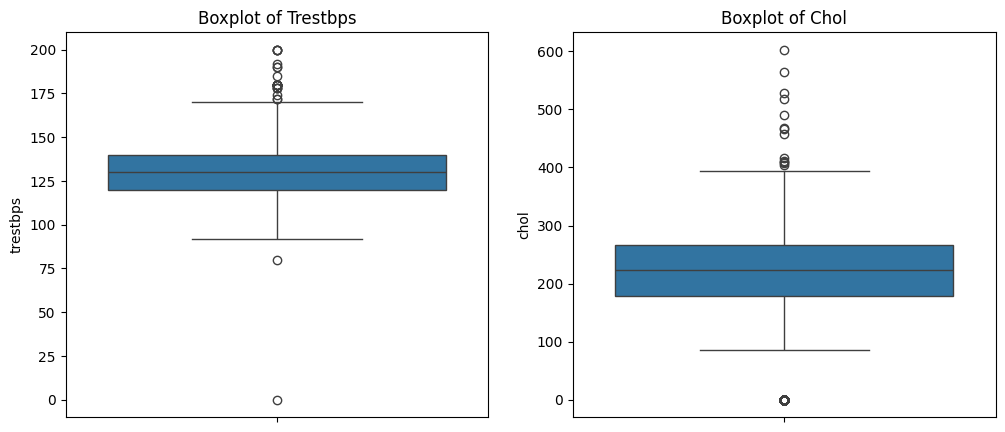

In [21]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['trestbps'])
plt.title('Boxplot of Trestbps')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['chol'])
plt.title('Boxplot of Chol')

plt.show()

In [22]:
df_copy=df.copy()
for col in ['trestbps', 'chol']:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    
    maximum = Q3 + (1.5 * IQR)
    minimum = Q1 - (1.5 * IQR)
    
    df_copy[col] = np.where(df_copy[col] > maximum, maximum, df_copy[col])
    df_copy[col] = np.where(df_copy[col] < minimum, minimum, df_copy[col])

In [23]:
df_copy=df.copy()

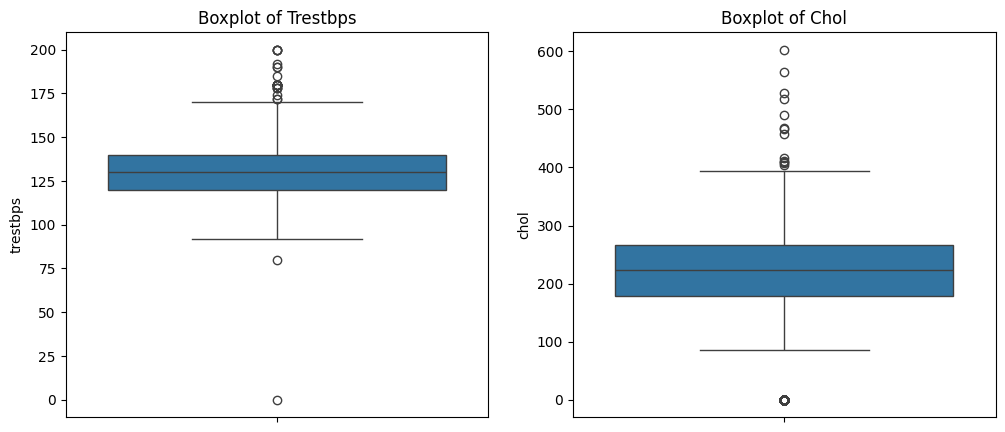

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df_copy['trestbps'])
plt.title('Boxplot of Trestbps')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_copy['chol'])
plt.title('Boxplot of Chol')

plt.show()

In [ ]:
df_copy=df.copy()
for col in ['trestbps', 'chol']:
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    
    maximum = Q3 + (1.5 * IQR)
    minimum = Q1 - (1.5 * IQR)
    
    kondisi_lower_than = df_copy[col] < minimum
    kondisi_more_than = df_copy[col] > maximum
 
    df_copy.drop(df_copy[kondisi_lower_than].index, inplace=True)
    df_copy.drop(df_copy[kondisi_more_than].index, inplace=True)

### Duplicates Data

In [26]:
df.duplicated().sum()

0

In [27]:
df.drop_duplicates(inplace=True)

### Data Encoding

In [28]:
import pandas as pd
size_df=pd.DataFrame([
    ['green','M',10.1,'class2'],
    ['red','L',13.5,'class1'],
    ['blue','XL',15.3,'class2']
])
size_df.columns=['color','size','price','classlabel']
size_df

,color,size,price,classlabel
0,green,M,10.1,class2
1,red,L,13.5,class1
2,blue,XL,15.3,class2


In [29]:
size_mapping={'XL':3,
              'L':2,
              'M':1}

In [30]:
size_df['size']=size_df['size'].map(size_mapping)
size_df

,color,size,price,classlabel
0,green,1,10.1,class2
1,red,2,13.5,class1
2,blue,3,15.3,class2


In [31]:
inv_size_mapping={v: k for k, v in size_mapping.items()}
size_df['size'].map(inv_size_mapping)

0     M
1     L
2    XL
Name: size, dtype: object

### Encoding Class Labels

In [32]:
import numpy as np
class_mapping={label: idx for idx, label in
               enumerate(np.unique(size_df['classlabel']))}
class_mapping

{'class1': 0, 'class2': 1}

In [33]:
size_df['classlabel']=size_df['classlabel'].map(class_mapping)
size_df

,color,size,price,classlabel
0,green,1,10.1,1
1,red,2,13.5,0
2,blue,3,15.3,1


In [34]:
inv_class_mapping={v: k for k,v in class_mapping.items()}
size_df['classlabel']=size_df['classlabel'].map(inv_class_mapping)
size_df

,color,size,price,classlabel
0,green,1,10.1,class2
1,red,2,13.5,class1
2,blue,3,15.3,class2


In [35]:
from sklearn.preprocessing import LabelEncoder
class_le=LabelEncoder()
y=class_le.fit_transform(size_df['classlabel'].values)
y

array([1, 0, 1])

In [36]:
class_le.inverse_transform(y)

array(['class2', 'class1', 'class2'], dtype=object)

### One Hot Encoding

In [37]:
X=size_df[['color', 'size', 'price']].values
color_le=LabelEncoder()
X[:,0]=color_le.fit_transform(X[:,0])
X

array([[1, 1, 10.1],
       [2, 2, 13.5],
       [0, 3, 15.3]], dtype=object)

In [38]:
from sklearn.preprocessing import OneHotEncoder
X=size_df[['color','size','price']].values
color_ohe=OneHotEncoder()
color_ohe.fit_transform(X[:,0].reshape(-1,1)).toarray()

array([[0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [39]:
from sklearn.compose import ColumnTransformer
X=size_df[['color','size','price']].values
c_transf=ColumnTransformer([
    ('onehot',OneHotEncoder(),[0]),
    ('nothing','passthrough',[1,2])
])
c_transf.fit_transform(X).astype(float)

array([[ 0. ,  1. ,  0. ,  1. , 10.1],
       [ 0. ,  0. ,  1. ,  2. , 13.5],
       [ 1. ,  0. ,  0. ,  3. , 15.3]])

In [40]:
pd.get_dummies(size_df[['price','color','size']])

,price,size,color_blue,color_green,color_red
0,10.1,1,False,True,False
1,13.5,2,False,False,True
2,15.3,3,True,False,False


In [41]:
pd.get_dummies(size_df[['price','color','size']],
               drop_first=True)

,price,size,color_green,color_red
0,10.1,1,True,False
1,13.5,2,False,True
2,15.3,3,False,False


In [42]:
color_ohe=OneHotEncoder(categories='auto',drop='first')
c_transf=ColumnTransformer([
    ('onehot',color_ohe,[0]),
    ('nothing','passthrough',[1,2])
])
c_transf.fit_transform(X).astype(float)

array([[ 1. ,  0. ,  1. , 10.1],
       [ 0. ,  1. ,  2. , 13.5],
       [ 0. ,  0. ,  3. , 15.3]])

In [43]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(sparse_output=False)
encoded_sex=encoder.fit_transform(df[['sex']])
encoded_df=pd.DataFrame(encoded_sex, columns=encoder.get_feature_names_out(['sex']))
df_encoded=pd.concat([df, encoded_df],axis=1)
df_encoded.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,sex_Female,sex_Male
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,0.0,1.0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,0.0,1.0
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,0.0,1.0
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,0.0,1.0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,1.0,0.0


## Min Max Normalization

###### Normalisasi -> Merubah dalam suatu rentang tertentu

###### $$x_{norm}^{(i)}=\frac{x^{(i)}-x_{min}}{x_{max}-x_{min}}$$

###### Standarisasi => Agar data memiliki rata-rata 0 dan standar deviasi 1

###### $$x_{std}^{(i)}=\frac{x^{(i)}-\mu_x}{\sigma_x}$$

In [95]:
ex=np.array([0,1,2,3,4,5])
print('array:', ex)
print('standardized:', (ex-ex.mean())/ex.std())
print('normalized:',(ex-ex.min())/(ex.max()-ex.min()))

array: [0 1 2 3 4 5]
standardized: [-1.46385011 -0.87831007 -0.29277002  0.29277002  0.87831007  1.46385011]
normalized: [0.  0.2 0.4 0.6 0.8 1. ]


In [45]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler  
data={
    'age':[23,45,56,67,34],
    'chol':[220,240,210,180,250],
    'trestbps':[130,150,120,140,160]
}
df=pd.DataFrame(data)
df

,age,chol,trestbps
0,23,220,130
1,45,240,150
2,56,210,120
3,67,180,140
4,34,250,160


In [ ]:
scaler=MinMaxScaler()
df_normalized=scaler.fit_transform(df)
df_normalized=pd.DataFrame(df_normalized,columns=df.columns)
df_normalized

,age,chol,trestbps
0,0.00,0.571429,0.25
1,0.50,0.857143,0.75
2,0.75,0.428571,0.00
3,1.00,0.000000,0.50
4,0.25,1.000000,1.00


## Latihan Soal

### Soal No.1

In [47]:
df=pd.read_csv('Data\heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


#### Bagian a)

In [48]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

#### Bagian b)

In [49]:
df['trestbps'].fillna(df['trestbps'].median(), inplace=True)
df['chol'].fillna(df['chol'].median(), inplace=True)

#### Bagian c)

In [50]:
df['slope'].fillna(df['slope'].mode()[0], inplace=True)
df['thal'].fillna(df['thal'].mode()[0], inplace=True)

#### Bagian d)

In [51]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps      0
chol          0
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope         0
ca          611
thal          0
num           0
dtype: int64

### Soal No.2

#### Bagian a)

In [52]:
df = pd.get_dummies(df, columns=['sex'], prefix='sex')

In [53]:
df.head()

,id,age,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,sex_Female,sex_Male
0,1,63,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,False,True
1,2,67,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,False,True
2,3,67,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,False,True
3,4,37,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,False,True
4,5,41,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,True,False


#### Bagian b)

In [54]:
df['dataset']

0          Cleveland
1          Cleveland
2          Cleveland
3          Cleveland
4          Cleveland
           ...      
915    VA Long Beach
916    VA Long Beach
917    VA Long Beach
918    VA Long Beach
919    VA Long Beach
Name: dataset, Length: 920, dtype: object

In [55]:
le=LabelEncoder()
df['dataset']=le.fit_transform(df['dataset'])

In [56]:
df.head()

,id,age,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,sex_Female,sex_Male
0,1,63,0,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,False,True
1,2,67,0,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2,False,True
2,3,67,0,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,False,True
3,4,37,0,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,False,True
4,5,41,0,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,True,False


### Soal No.3

In [57]:
numerical_columns=df.select_dtypes(include=['number']).columns

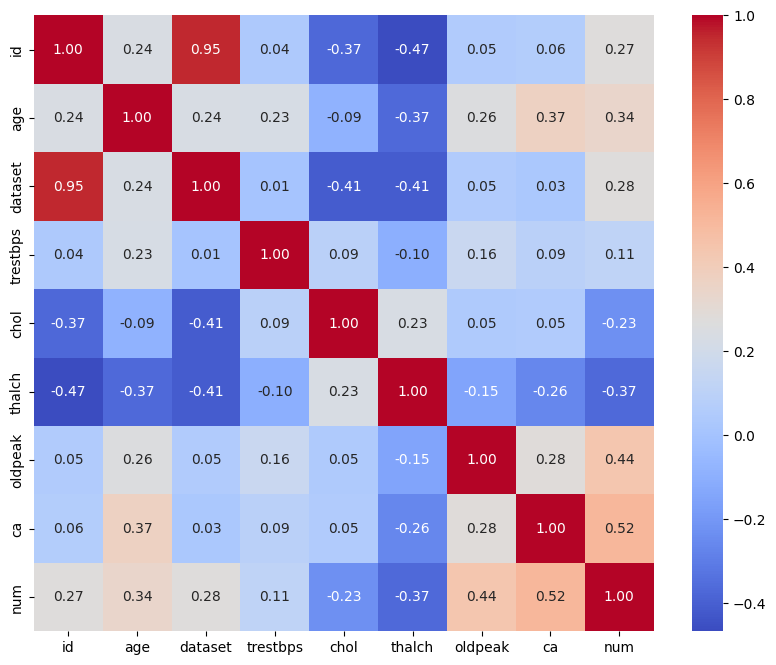

In [58]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### Soal No.4

In [59]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()

df['age'] = scaler_minmax.fit_transform(df[['age']])
df['trestbps'] = scaler_minmax.fit_transform(df[['trestbps']])
df['chol'] = scaler_standard.fit_transform(df[['chol']])
df['thalch'] = scaler_standard.fit_transform(df[['thalch']])

In [60]:
df.head()

,id,age,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num,sex_Female,sex_Male
0,1,0.714286,0,typical angina,0.725,0.303643,True,lv hypertrophy,0.480653,False,2.3,downsloping,0.0,fixed defect,0,False,True
1,2,0.795918,0,asymptomatic,0.800,0.789967,False,lv hypertrophy,-1.140262,True,1.5,flat,3.0,normal,2,False,True
2,3,0.795918,0,asymptomatic,0.600,0.266939,False,lv hypertrophy,-0.329805,True,2.6,flat,2.0,reversable defect,1,False,True
3,4,0.183673,0,non-anginal,0.650,0.459634,False,normal,1.908602,False,3.5,downsloping,0.0,normal,0,False,True
4,5,0.265306,0,atypical angina,0.650,0.037541,False,lv hypertrophy,1.329704,False,1.4,upsloping,0.0,normal,0,True,False


### Soal No.5

In [61]:
missing_values=df.isnull().sum()
missing_percentage=(missing_values/len(df))*100
missing_summary=pd.DataFrame({'Total Missing': missing_values, 'Missing Percentage (%)':missing_percentage})
missing_summary = missing_summary.loc[['ca', 'slope']]
missing_summary

,Total Missing,Missing Percentage (%)
ca,611,66.413043
slope,0,0.000000


In [62]:
for col in ['ca', 'slope']:
    if df[col].isnull().mean() > 0.5:
        df.drop(columns=[col], inplace=True)
    else:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          920 non-null    int64  
 1   age         920 non-null    float64
 2   dataset     920 non-null    int32  
 3   cp          920 non-null    object 
 4   trestbps    920 non-null    float64
 5   chol        920 non-null    float64
 6   fbs         830 non-null    object 
 7   restecg     918 non-null    object 
 8   thalch      865 non-null    float64
 9   exang       865 non-null    object 
 10  oldpeak     858 non-null    float64
 11  slope       920 non-null    object 
 12  thal        920 non-null    object 
 13  num         920 non-null    int64  
 14  sex_Female  920 non-null    bool   
 15  sex_Male    920 non-null    bool   
dtypes: bool(2), float64(5), int32(1), int64(2), object(6)
memory usage: 99.0+ KB


### Soal No.6

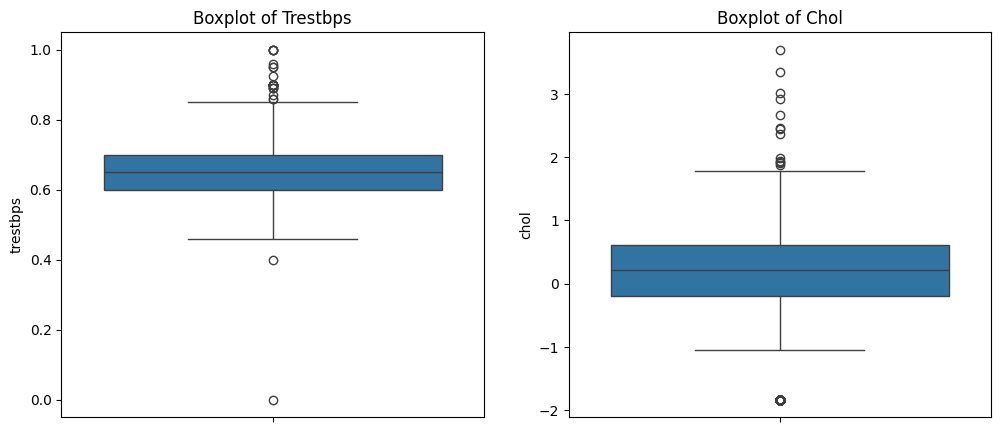

In [64]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['trestbps'])
plt.title('Boxplot of Trestbps')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['chol'])
plt.title('Boxplot of Chol')

plt.show()

In [65]:
for col in ['trestbps', 'chol']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    maximum = Q3 + (1.5 * IQR)
    minimum = Q1 - (1.5 * IQR)
    
    df[col] = np.where(df[col] > maximum, maximum, df[col])
    df[col] = np.where(df[col] < minimum, minimum, df[col])

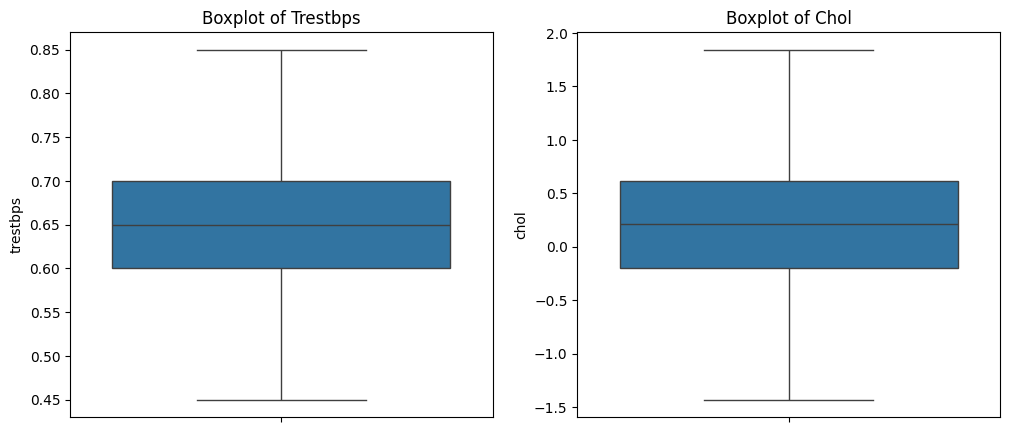

In [66]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(y=df['trestbps'])
plt.title('Boxplot of Trestbps')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['chol'])
plt.title('Boxplot of Chol')

plt.show()

### Soal No.7

In [67]:
from sklearn.model_selection import train_test_split


In [68]:
X = df.drop(columns=['num'])
y = df['num']

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)